In [1]:
import pandas as pd
import numpy as np
import time
import pickle
import warnings
warnings.filterwarnings('ignore')
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# ML Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ========================================
# CONFIGURATION
# ========================================

INPUT_FILE = "archive/full_df_binary_labels.csv"
BASE_MODEL_DIR = "trained_models/ml/"
TEST_SIZE = 0.2
RANDOM_STATE = 42
SAVE_MODELS = True

# ========================================
# PER-MODEL DATASET SIZE CONTROL
# ========================================
# Set the number of rows to use for each model
# None = use full dataset
# Integer = use that many rows (will be sampled from full dataset)

MODEL_SAMPLE_SIZES = {
    'Random Forest': None,        # Fast - use full dataset
    'Decision Tree': None,        # Fast - use full dataset
    'XGBoost': None,              # Fast - use full dataset
    'KNN': 50000,                 # SLOW - use only 50k rows
    'SVM': 100000,                # VERY SLOW - use only 100k rows
    'Naive Bayes': None           # Fast - use full dataset
}

print("📊 Per-Model Sample Sizes:")
for model, size in MODEL_SAMPLE_SIZES.items():
    size_str = 'Full dataset' if size is None else f'{size:,} rows'
    print(f"   {model}: {size_str}")

# Create base directory
os.makedirs(BASE_MODEL_DIR, exist_ok=True)
print(f"\n✅ Base model directory: {BASE_MODEL_DIR}")

📊 Per-Model Sample Sizes:
   Random Forest: Full dataset
   Decision Tree: Full dataset
   XGBoost: Full dataset
   KNN: 50,000 rows
   SVM: 100,000 rows
   Naive Bayes: Full dataset

✅ Base model directory: trained_models/ml/


In [3]:
# ========================================
# LOAD DATASET (Memory-Efficient)
# ========================================

CHUNK_SIZE = 100000
MAX_ROWS = None  # None = load all data, or set a limit

# Initialize lists to store chunks
chunks = []
total_rows = 0

# Read in chunks
print("⏳ Reading data...")
for i, chunk in enumerate(pd.read_csv(INPUT_FILE, chunksize=CHUNK_SIZE)):
    # Check if we've reached max rows
    if MAX_ROWS and total_rows >= MAX_ROWS:
        break

    # If this chunk would exceed MAX_ROWS, truncate it
    if MAX_ROWS and total_rows + len(chunk) > MAX_ROWS:
        chunk = chunk.head(MAX_ROWS - total_rows)

    chunks.append(chunk)
    total_rows += len(chunk)

    # Progress update every 5 chunks
    if (i + 1) % 5 == 0:
        print(f"   Loaded chunk {i+1}: {total_rows:,} rows total")

print(f"\n✅ Loaded {len(chunks)} chunks")
print(f"✅ Total rows: {total_rows:,}")

# Combine chunks
print("\n🔗 Combining chunks...")
df_full = pd.concat(chunks, ignore_index=True)
del chunks  # Free memory

print(f"✅ Dataset shape: {df_full.shape}")
print(f"✅ Columns: {len(df_full.columns)}")
print(f"\nFirst few columns: {list(df_full.columns)[:5]}")

⏳ Reading data...
   Loaded chunk 5: 500,000 rows total
   Loaded chunk 10: 1,000,000 rows total
   Loaded chunk 15: 1,500,000 rows total
   Loaded chunk 20: 2,000,000 rows total
   Loaded chunk 25: 2,500,000 rows total
   Loaded chunk 30: 3,000,000 rows total
   Loaded chunk 35: 3,500,000 rows total
   Loaded chunk 40: 4,000,000 rows total
   Loaded chunk 45: 4,500,000 rows total
   Loaded chunk 50: 5,000,000 rows total
   Loaded chunk 55: 5,500,000 rows total
   Loaded chunk 60: 6,000,000 rows total
   Loaded chunk 65: 6,500,000 rows total
   Loaded chunk 70: 7,000,000 rows total
   Loaded chunk 75: 7,500,000 rows total
   Loaded chunk 80: 8,000,000 rows total
   Loaded chunk 85: 8,500,000 rows total
   Loaded chunk 90: 9,000,000 rows total
   Loaded chunk 95: 9,500,000 rows total
   Loaded chunk 100: 10,000,000 rows total
   Loaded chunk 105: 10,500,000 rows total
   Loaded chunk 110: 11,000,000 rows total
   Loaded chunk 115: 11,500,000 rows total
   Loaded chunk 120: 12,000,000 ro

In [4]:
# Display first few rows
print("📊 First 5 rows:")
display(df_full.head(20))

# Memory usage
print(f"\n💾 Memory usage: {df_full.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Data info
print("\n📋 Dataset Info:")
print(f"   Shape: {df_full.shape}")
print(f"   Columns: {len(df_full.columns)}")
print(f"   Data types: {df_full.dtypes.value_counts().to_dict()}")

📊 First 5 rows:


,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Mean,Fwd Pkt Len Std,...,Subflow Bwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Idle Mean,Idle Max,Idle Min,Label,Label_Binary
0,0,0,112641719,3,0,0.0,0.0,0.0,0.000000,0.000000,...,0,-1,-1,0,0,56320859.5,56320958.0,56320761.0,Benign,0
1,0,0,112641466,3,0,0.0,0.0,0.0,0.000000,0.000000,...,0,-1,-1,0,0,56320733.0,56320814.0,56320652.0,Benign,0
2,0,0,112638623,3,0,0.0,0.0,0.0,0.000000,0.000000,...,0,-1,-1,0,0,56319311.5,56319525.0,56319098.0,Benign,0
3,22,6,6453966,15,10,1239.0,2273.0,744.0,82.600000,196.741237,...,2273,65535,233,6,32,0.0,0.0,0.0,Benign,0
4,22,6,8804066,14,11,1143.0,2209.0,744.0,81.642857,203.745545,...,2209,5808,233,6,32,0.0,0.0,0.0,Benign,0
5,22,6,6989341,16,12,1239.0,2273.0,744.0,77.437500,190.831154,...,2273,5808,234,7,20,0.0,0.0,0.0,Benign,0
6,0,0,112640480,3,0,0.0,0.0,0.0,0.000000,0.000000,...,0,-1,-1,0,0,56320240.0,56320384.0,56320096.0,Benign,0
7,0,0,112641244,3,0,0.0,0.0,0.0,0.000000,0.000000,...,0,-1,-1,0,0,56320622.0,56320666.0,56320578.0,Benign,0
8,80,6,476513,5,3,211.0,463.0,211.0,42.200000,94.362069,...,463,14600,219,1,32,0.0,0.0,0.0,Benign,0
9,80,6,475048,5,3,220.0,472.0,220.0,44.000000,98.386991,...,472,14600,219,1,32,0.0,0.0,0.0,Benign,0



💾 Memory usage: 8184.55 MB

📋 Dataset Info:
   Shape: (16232943, 59)
   Columns: 59
   Data types: {dtype('float64'): 37, dtype('int64'): 21, dtype('O'): 1}


📊 SKEWNESS ANALYSIS

📈 SKEWNESS SUMMARY:
          Feature     Skewness  Abs_Skewness                                 Interpretation Direction
    Flow IAT Mean -3378.166598   3378.166598 🔴 Highly Skewed (NEEDS scaling/transformation)   Left ⬅️
     Fwd IAT Mean -3377.632895   3377.632895 🔴 Highly Skewed (NEEDS scaling/transformation)   Left ⬅️
         Idle Min  3339.096062   3339.096062 🔴 Highly Skewed (NEEDS scaling/transformation)  Right ➡️
      Pkt Len Var  1863.599200   1863.599200 🔴 Highly Skewed (NEEDS scaling/transformation)  Right ➡️
      Fwd IAT Tot -1434.865631   1434.865631 🔴 Highly Skewed (NEEDS scaling/transformation)   Left ⬅️
    Flow Duration -1434.821888   1434.821888 🔴 Highly Skewed (NEEDS scaling/transformation)   Left ⬅️
         Idle Max  1331.616505   1331.616505 🔴 Highly Skewed (NEEDS scaling/transformation)  Right ➡️
        Idle Mean  1261.869806   1261.869806 🔴 Highly Skewed (NEEDS scaling/transformation)  Right ➡️
     Flow IAT Std  1208.472260   1208.472

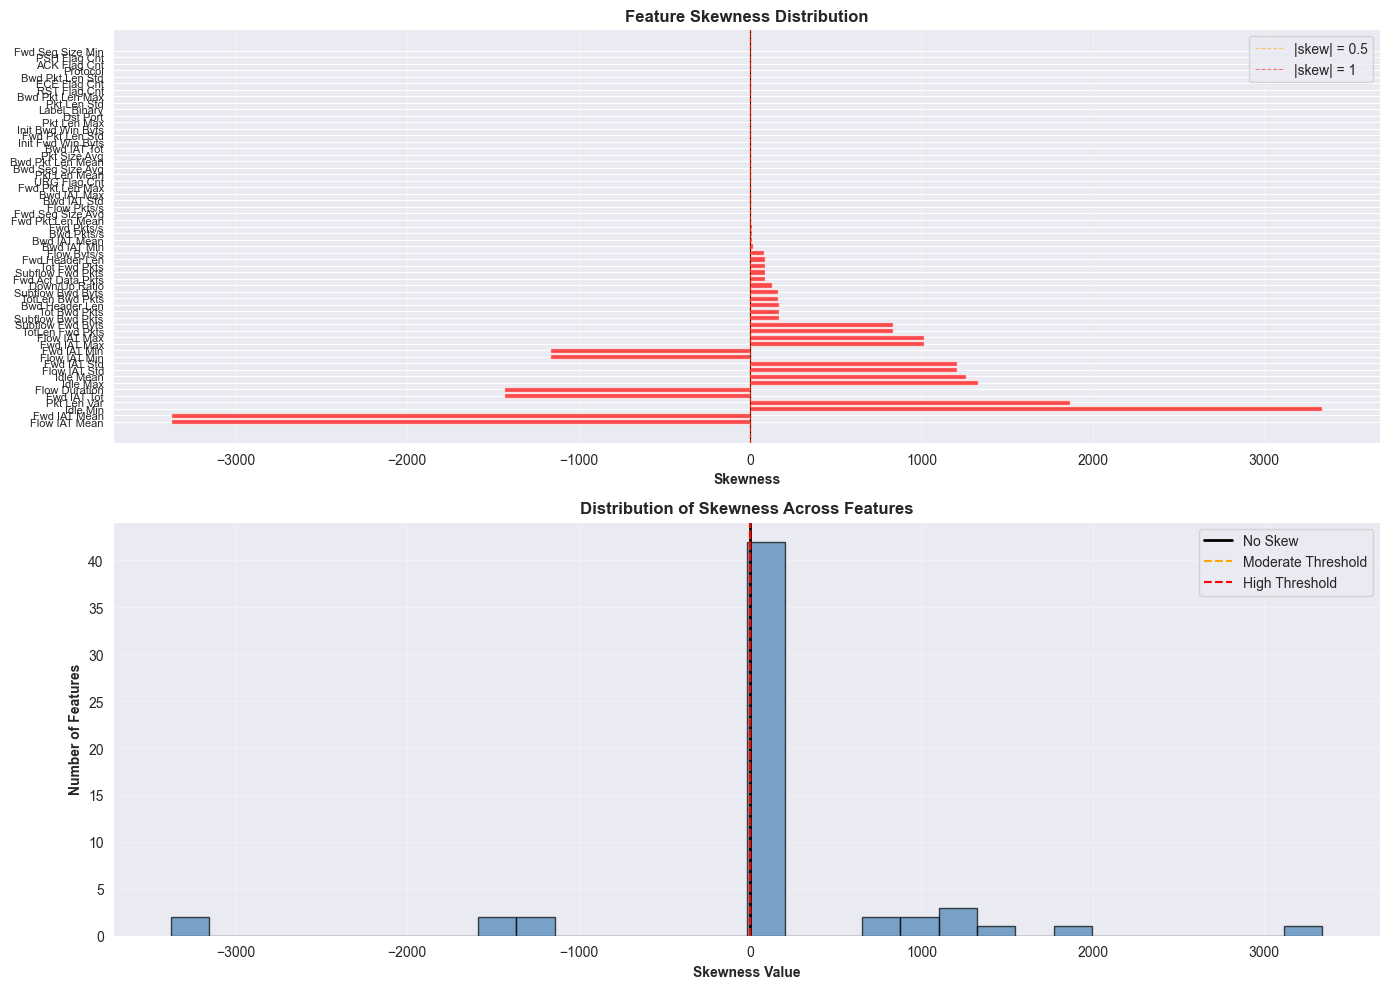



💡 RECOMMENDATIONS:
   1. Features with |skew| < 0.5: Use StandardScaler
   2. Features with |skew| ≥ 0.5: Consider:
      • Log transformation (for right-skewed data)
      • Square root transformation
      • Box-Cox transformation
      • RobustScaler (less sensitive to outliers)
   3. After transformation, apply StandardScaler


In [5]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate skewness for all numeric columns
print("📊 SKEWNESS ANALYSIS")
print("=" * 80)

# Get numeric columns only
numeric_cols = df_full.select_dtypes(include=[np.number]).columns

# Calculate skewness
skewness = df_full[numeric_cols].skew().sort_values(ascending=False)

# Create a DataFrame for better visualization
skew_df = pd.DataFrame({
    'Feature': skewness.index,
    'Skewness': skewness.values,
    'Abs_Skewness': np.abs(skewness.values)
}).sort_values('Abs_Skewness', ascending=False)

# Add interpretation
def interpret_skew(skew):
    abs_skew = abs(skew)
    if abs_skew < 0.5:
        return '✅ Symmetric (No scaling needed)'
    elif abs_skew < 1:
        return '⚠️ Moderately Skewed (Consider scaling)'
    else:
        return '🔴 Highly Skewed (NEEDS scaling/transformation)'

skew_df['Interpretation'] = skew_df['Skewness'].apply(interpret_skew)
skew_df['Direction'] = skew_df['Skewness'].apply(lambda x: 'Right ➡️' if x > 0 else 'Left ⬅️' if x < 0 else 'Neutral')

# Display results
print("\n📈 SKEWNESS SUMMARY:")
print(skew_df.to_string(index=False))

# Summary statistics
print("\n\n📊 SUMMARY STATISTICS:")
print(f"   Total numeric features: {len(numeric_cols)}")
print(f"   Symmetric (|skew| < 0.5): {len(skew_df[skew_df['Abs_Skewness'] < 0.5])}")
print(f"   Moderately skewed (0.5 ≤ |skew| < 1): {len(skew_df[(skew_df['Abs_Skewness'] >= 0.5) & (skew_df['Abs_Skewness'] < 1)])}")
print(f"   Highly skewed (|skew| ≥ 1): {len(skew_df[skew_df['Abs_Skewness'] >= 1])}")

# Features that need scaling/transformation
print("\n\n🔴 FEATURES REQUIRING SCALING/TRANSFORMATION (|skew| ≥ 0.5):")
needs_scaling = skew_df[skew_df['Abs_Skewness'] >= 0.5]['Feature'].tolist()
print(f"   {len(needs_scaling)} features:")
for feat in needs_scaling:
    skew_val = skew_df[skew_df['Feature'] == feat]['Skewness'].values[0]
    print(f"   • {feat}: {skew_val:.3f}")

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Bar chart of skewness
ax1 = axes[0]
colors = ['red' if abs(x) >= 1 else 'orange' if abs(x) >= 0.5 else 'green'
          for x in skew_df['Skewness']]
bars = ax1.barh(range(len(skew_df)), skew_df['Skewness'], color=colors, alpha=0.7)
ax1.set_yticks(range(len(skew_df)))
ax1.set_yticklabels(skew_df['Feature'], fontsize=8)
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax1.axvline(x=0.5, color='orange', linestyle='--', linewidth=0.8, alpha=0.5, label='|skew| = 0.5')
ax1.axvline(x=-0.5, color='orange', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.axvline(x=1, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label='|skew| = 1')
ax1.axvline(x=-1, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.set_xlabel('Skewness', fontsize=10, fontweight='bold')
ax1.set_title('Feature Skewness Distribution', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# Plot 2: Histogram of skewness values
ax2 = axes[1]
ax2.hist(skew_df['Skewness'], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=2, label='No Skew')
ax2.axvline(x=0.5, color='orange', linestyle='--', linewidth=1.5, label='Moderate Threshold')
ax2.axvline(x=-0.5, color='orange', linestyle='--', linewidth=1.5)
ax2.axvline(x=1, color='red', linestyle='--', linewidth=1.5, label='High Threshold')
ax2.axvline(x=-1, color='red', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Skewness Value', fontsize=10, fontweight='bold')
ax2.set_ylabel('Number of Features', fontsize=10, fontweight='bold')
ax2.set_title('Distribution of Skewness Across Features', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n\n💡 RECOMMENDATIONS:")
print("   1. Features with |skew| < 0.5: Use StandardScaler")
print("   2. Features with |skew| ≥ 0.5: Consider:")
print("      • Log transformation (for right-skewed data)")
print("      • Square root transformation")
print("      • Box-Cox transformation")
print("      • RobustScaler (less sensitive to outliers)")
print("   3. After transformation, apply StandardScaler")

🎯 FEATURE-SPECIFIC SCALING RECOMMENDATIONS FOR CIC-IDS-2018

📊 DETAILED FEATURE-BY-FEATURE RECOMMENDATIONS:

🔧 POWERTRANSFORMER (54 features)

• Flow IAT Mean
  Skewness:   -3378.17 | Outliers:  19.9% | Zeros:   0.6% | Negative: True
  Range: [-8.28e+11, 1.20e+08]
  → Extreme skew/outliers

• Fwd IAT Mean
  Skewness:   -3377.63 | Outliers:  19.0% | Zeros:  28.3% | Negative: True
  Range: [-8.28e+11, 1.20e+08]
  → Extreme skew/outliers

• Idle Min
  Skewness:    3339.10 | Outliers:  14.5% | Zeros:  85.5% | Negative: False
  Range: [0.00e+00, 2.40e+11]
  → Extreme skew/outliers

• Pkt Len Var
  Skewness:    1863.60 | Outliers:   4.6% | Zeros:  31.7% | Negative: False
  Range: [0.00e+00, 5.19e+08]
  → Extreme skew/outliers

• Fwd IAT Tot
  Skewness:   -1434.87 | Outliers:  15.4% | Zeros:  28.3% | Negative: True
  Range: [-9.19e+11, 1.20e+08]
  → Extreme skew/outliers

• Flow Duration
  Skewness:   -1434.82 | Outliers:  15.2% | Zeros:   0.6% | Negative: True
  Range: [-9.19e+11, 1.20e+08]


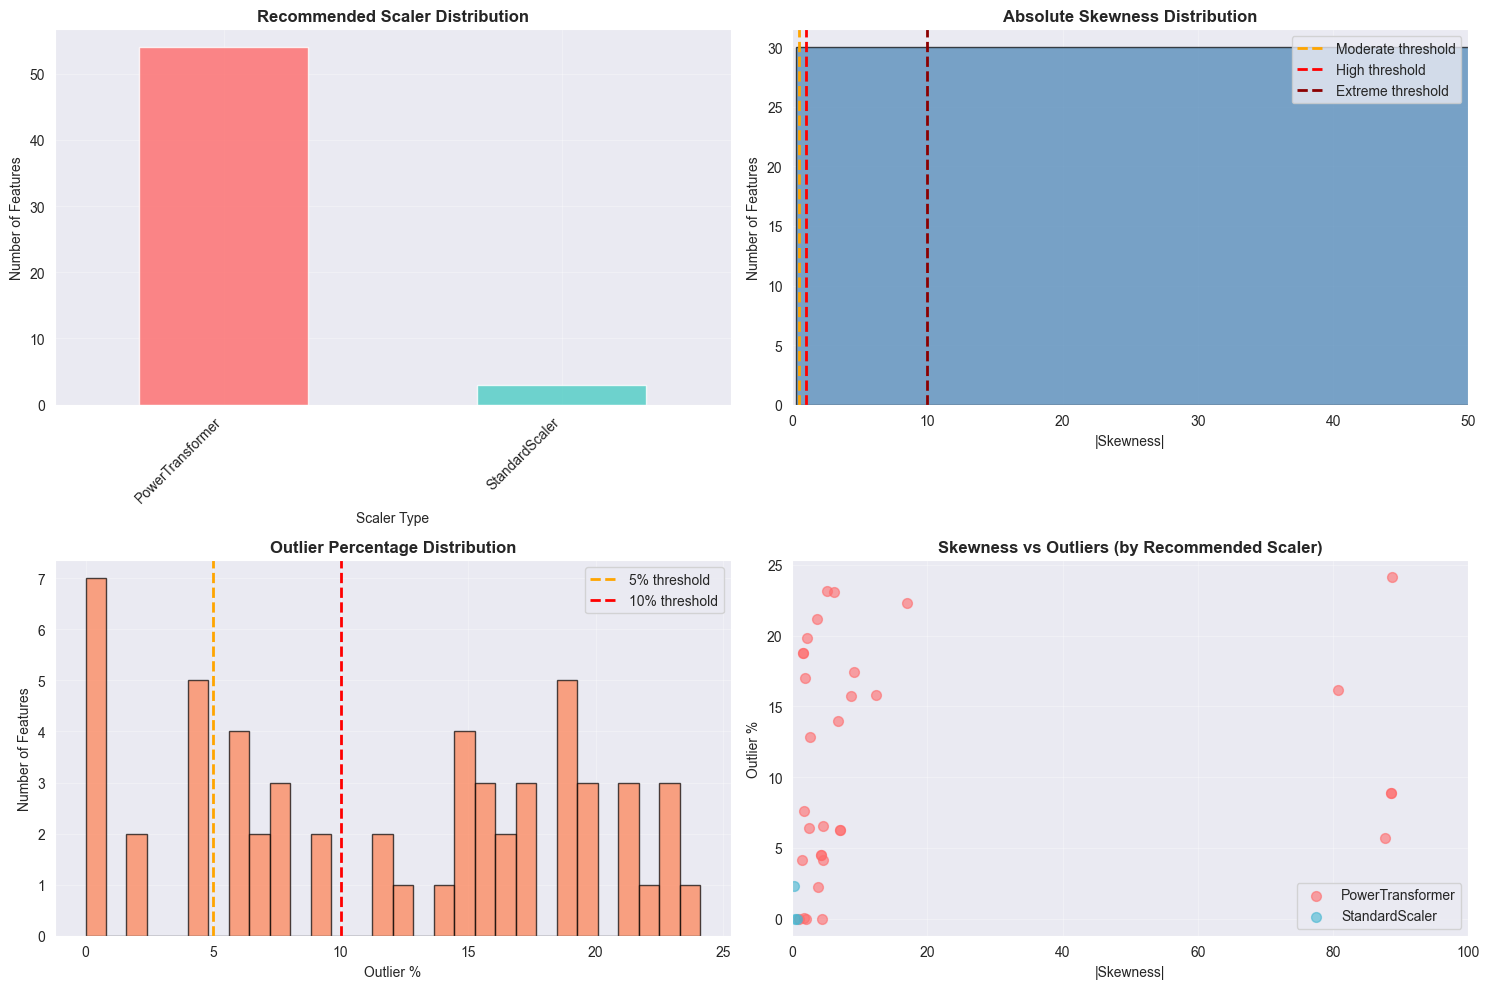



📝 CODE IMPLEMENTATION:

🎯 OPTION 1: Simple Uniform Approach (RECOMMENDED)
--------------------------------------------------------------------------------

from sklearn.preprocessing import PowerTransformer

# Separate features and target
X = df_full.drop('Label_Binary', axis=1)
y = df_full['Label_Binary']

# Apply PowerTransformer to ALL features
pt = PowerTransformer(method='yeo-johnson', standardize=True)
X_scaled = pt.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# Save for later use
import joblib
joblib.dump(pt, 'power_transformer_all.pkl')


🔀 OPTION 2: Mixed Approach (More Complex)
--------------------------------------------------------------------------------

from sklearn.preprocessing import PowerTransformer, RobustScaler, StandardScaler
from sklearn.compose import ColumnTransformer

# Define feature groups
power_features = ['Flow IAT Mean', 'Fwd IAT Mean', 'Idle Min']  # ... full list
robust_features = [

In [8]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PowerTransformer, RobustScaler, StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt

print("🎯 FEATURE-SPECIFIC SCALING RECOMMENDATIONS FOR CIC-IDS-2018")
print("=" * 80)

# Analyze each feature's characteristics
feature_analysis = []

numeric_cols = [col for col in df_full.select_dtypes(include=[np.number]).columns
                if col != 'Label_Binary']

for col in numeric_cols:
    # Calculate statistics
    skewness = df_full[col].skew()
    abs_skew = abs(skewness)

    # Check for negative values
    has_negative = (df_full[col] < 0).any()

    # Check for zeros
    zero_pct = (df_full[col] == 0).sum() / len(df_full) * 100

    # Outlier detection (IQR method)
    Q1 = df_full[col].quantile(0.25)
    Q3 = df_full[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_pct = ((df_full[col] < (Q1 - 1.5 * IQR)) | (df_full[col] > (Q3 + 1.5 * IQR))).sum() / len(df_full) * 100

    # Range
    min_val = df_full[col].min()
    max_val = df_full[col].max()

    # Determine best scaler
    if abs_skew < 0.5 and outlier_pct < 5:
        scaler = "StandardScaler"
        reason = "Low skew, few outliers"
    elif abs_skew >= 10 or outlier_pct > 20:
        scaler = "PowerTransformer"
        reason = "Extreme skew/outliers"
    elif abs_skew >= 1:
        if has_negative:
            scaler = "PowerTransformer"
            reason = "High skew + negative values"
        else:
            scaler = "PowerTransformer"
            reason = "High skew"
    elif outlier_pct > 10:
        scaler = "RobustScaler"
        reason = "Many outliers"
    else:
        scaler = "StandardScaler"
        reason = "Moderate skew, few outliers"

    feature_analysis.append({
        'Feature': col,
        'Skewness': skewness,
        'Abs_Skew': abs_skew,
        'Has_Negative': has_negative,
        'Zero_%': zero_pct,
        'Outlier_%': outlier_pct,
        'Min': min_val,
        'Max': max_val,
        'Recommended_Scaler': scaler,
        'Reason': reason
    })

# Create DataFrame
analysis_df = pd.DataFrame(feature_analysis)
analysis_df = analysis_df.sort_values('Abs_Skew', ascending=False)

# Display recommendations
print("\n📊 DETAILED FEATURE-BY-FEATURE RECOMMENDATIONS:")
print("=" * 80)

# Group by recommended scaler
scaler_groups = analysis_df.groupby('Recommended_Scaler')

for scaler_name, group in scaler_groups:
    print(f"\n{'='*80}")
    print(f"🔧 {scaler_name.upper()} ({len(group)} features)")
    print(f"{'='*80}")

    for _, row in group.head(15).iterrows():  # Show top 15 per group
        print(f"\n• {row['Feature']}")
        print(f"  Skewness: {row['Skewness']:>10.2f} | Outliers: {row['Outlier_%']:>5.1f}% | "
              f"Zeros: {row['Zero_%']:>5.1f}% | Negative: {row['Has_Negative']}")
        print(f"  Range: [{row['Min']:.2e}, {row['Max']:.2e}]")
        print(f"  → {row['Reason']}")

    if len(group) > 15:
        print(f"\n  ... and {len(group) - 15} more features")

# Summary statistics
print("\n\n📊 SCALER DISTRIBUTION SUMMARY:")
print("=" * 80)
scaler_counts = analysis_df['Recommended_Scaler'].value_counts()
print(scaler_counts.to_string())

# PRACTICAL RECOMMENDATION
print("\n\n🎯 PRACTICAL RECOMMENDATION FOR CIC-IDS-2018:")
print("=" * 80)
print("Given your dataset characteristics:")
print(f"  • {(analysis_df['Abs_Skew'] >= 1).sum()}/{len(analysis_df)} features have |skew| ≥ 1")
print(f"  • {(analysis_df['Abs_Skew'] >= 10).sum()}/{len(analysis_df)} features have EXTREME skew (≥10)")
print(f"  • {(analysis_df['Outlier_%'] > 10).sum()}/{len(analysis_df)} features have >10% outliers")
print(f"  • {(analysis_df['Has_Negative']).sum()}/{len(analysis_df)} features have negative values")

print("\n✅ BEST APPROACH: Use PowerTransformer for ALL features")
print("\nWhy uniform approach?")
print("  1. Simplicity - one scaler for all features")
print("  2. PowerTransformer handles all cases:")
print("     ✓ Extreme skewness (your main problem)")
print("     ✓ Negative values (Yeo-Johnson method)")
print("     ✓ Outliers (through transformation)")
print("  3. Better for ML models (more Gaussian distribution)")
print("  4. Includes standardization (mean=0, std=1)")

# Alternative: Mixed approach
print("\n\n🔀 ALTERNATIVE: Mixed Scaling Approach")
print("=" * 80)
print("If you want to optimize per feature type:")

# Create feature groups
power_features = analysis_df[analysis_df['Recommended_Scaler'] == 'PowerTransformer']['Feature'].tolist()
robust_features = analysis_df[analysis_df['Recommended_Scaler'] == 'RobustScaler']['Feature'].tolist()
standard_features = analysis_df[analysis_df['Recommended_Scaler'] == 'StandardScaler']['Feature'].tolist()

print(f"\n1️⃣ PowerTransformer ({len(power_features)} features):")
print(f"   {power_features[:5]}...")

print(f"\n2️⃣ RobustScaler ({len(robust_features)} features):")
if robust_features:
    print(f"   {robust_features[:5]}")
else:
    print(f"   None recommended")

print(f"\n3️⃣ StandardScaler ({len(standard_features)} features):")
if standard_features:
    print(f"   {standard_features[:5]}")
else:
    print(f"   None recommended")

# Visualization
print("\n\n📊 Creating visualization...")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Scaler recommendation distribution
ax1 = axes[0, 0]
scaler_counts.plot(kind='bar', ax=ax1, color=['#ff6b6b', '#4ecdc4', '#45b7d1'], alpha=0.8)
ax1.set_title('Recommended Scaler Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Scaler Type')
ax1.set_ylabel('Number of Features')
ax1.grid(alpha=0.3)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Plot 2: Skewness distribution
ax2 = axes[0, 1]
ax2.hist(analysis_df['Abs_Skew'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax2.axvline(x=0.5, color='orange', linestyle='--', linewidth=2, label='Moderate threshold')
ax2.axvline(x=1, color='red', linestyle='--', linewidth=2, label='High threshold')
ax2.axvline(x=10, color='darkred', linestyle='--', linewidth=2, label='Extreme threshold')
ax2.set_title('Absolute Skewness Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('|Skewness|')
ax2.set_ylabel('Number of Features')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_xlim(0, 50)  # Limit x-axis for better visibility

# Plot 3: Outlier percentage
ax3 = axes[1, 0]
ax3.hist(analysis_df['Outlier_%'], bins=30, color='coral', alpha=0.7, edgecolor='black')
ax3.axvline(x=5, color='orange', linestyle='--', linewidth=2, label='5% threshold')
ax3.axvline(x=10, color='red', linestyle='--', linewidth=2, label='10% threshold')
ax3.set_title('Outlier Percentage Distribution', fontsize=12, fontweight='bold')
ax3.set_xlabel('Outlier %')
ax3.set_ylabel('Number of Features')
ax3.legend()
ax3.grid(alpha=0.3)

# Plot 4: Skewness vs Outliers
ax4 = axes[1, 1]
colors = {'PowerTransformer': '#ff6b6b', 'RobustScaler': '#4ecdc4', 'StandardScaler': '#45b7d1'}
for scaler in analysis_df['Recommended_Scaler'].unique():
    mask = analysis_df['Recommended_Scaler'] == scaler
    ax4.scatter(analysis_df[mask]['Abs_Skew'],
               analysis_df[mask]['Outlier_%'],
               label=scaler, alpha=0.6, s=50, color=colors.get(scaler, 'gray'))
ax4.set_title('Skewness vs Outliers (by Recommended Scaler)', fontsize=12, fontweight='bold')
ax4.set_xlabel('|Skewness|')
ax4.set_ylabel('Outlier %')
ax4.legend()
ax4.grid(alpha=0.3)
ax4.set_xlim(0, 100)

plt.tight_layout()
plt.show()

# CODE EXAMPLES
print("\n\n📝 CODE IMPLEMENTATION:")
print("=" * 80)

print("\n🎯 OPTION 1: Simple Uniform Approach (RECOMMENDED)")
print("-" * 80)
print("""
from sklearn.preprocessing import PowerTransformer

# Separate features and target
X = df_full.drop('Label_Binary', axis=1)
y = df_full['Label_Binary']

# Apply PowerTransformer to ALL features
pt = PowerTransformer(method='yeo-johnson', standardize=True)
X_scaled = pt.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# Save for later use
import joblib
joblib.dump(pt, 'power_transformer_all.pkl')
""")

print("\n🔀 OPTION 2: Mixed Approach (More Complex)")
print("-" * 80)
print("""
from sklearn.preprocessing import PowerTransformer, RobustScaler, StandardScaler
from sklearn.compose import ColumnTransformer

# Define feature groups
power_features = """ + str(power_features[:3]) + """  # ... full list
robust_features = """ + str(robust_features[:3]) + """  # ... if any
standard_features = """ + str(standard_features[:3]) + """  # ... if any

# Create column transformer
transformers = [
    ('power', PowerTransformer(method='yeo-johnson'), power_features),
]

if robust_features:
    transformers.append(('robust', RobustScaler(), robust_features))
if standard_features:
    transformers.append(('standard', StandardScaler(), standard_features))

ct = ColumnTransformer(transformers=transformers, remainder='passthrough')

# Apply
X = df_full.drop('Label_Binary', axis=1)
y = df_full['Label_Binary']
X_scaled = ct.fit_transform(X)

# Save
import joblib
joblib.dump(ct, 'column_transformer_mixed.pkl')
""")

print("\n\n🏆 FINAL RECOMMENDATION:")
print("=" * 80)
print("✅ Use PowerTransformer for ALL features (Option 1)")
print("\nReasons:")
print("  1. Your data has EXTREME skewness (up to 3378!)")
print("  2. Simplicity - one transformer, easier to maintain")
print("  3. PowerTransformer handles all edge cases")
print("  4. Better performance in practice for imbalanced network traffic data")
print("  5. Easier to apply to test/production data")

# Save analysis
analysis_df.to_csv('feature_scaling_analysis.csv', index=False)
print("\n💾 Analysis saved to 'feature_scaling_analysis.csv'")